# Summary

1. Build process data as in the ```process_eda``` notebook
2. Build classification pipelines including variable importance
3. Compute and save **process embedding** based on top numerical features

Such embeddings will be used along with our Matching algorithm to find common/similar paths in process trees

### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/
  

# Introduction

The first few cells are taken from BH's ```process-name-curation``` notebook


In [1]:
%load_ext autoreload
%load_ext dotenv
#%load_ext quak 
%load_ext sql

In [2]:
%autoreload 1
%aimport acme4_explore

In [3]:
%%time
import acme4_explore
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from tqdm.auto import tqdm, trange
from collections import Counter
import warnings
import pickle
import gzip

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

import process_trees as pt

CPU times: user 4.05 s, sys: 60.9 ms, total: 4.11 s
Wall time: 719 ms


In [4]:
# Registers the current `tqdm` class with pandas.core.
tqdm.pandas()


In [5]:
lg.basicConfig(**acme4_explore.logging_config())
LOG = lg.getLogger("notebook")


In [7]:
db = acme4_explore.connect_db()
%sql db --alias duckdb
%config SqlMagic.displaycon=False
%config SqlMagic.autopandas=True


# Get data from the ```process_uber_summary``` table

* Flag processes from "badusers"
* Drop some numerical features too closely correlated with the baduser label


In [8]:
%%sql process <<
select * from process_uber_summary


In [9]:
## numerical features
num_col = process.select_dtypes(include=np.number).columns.tolist()
Drop = ['process_started_seconds', 'process_stop_seconds', 'parent_os_pid', 'os_pid', 'token_elevation_type']
# drop those - correlated with bad user's activity
for x in Drop:
    num_col.remove(x)

## flag badusers
process['is_bad'] = process['baduser'] = 0
process.loc[process["user_name"].isna(), "user_name"] = ""
process.loc[process["user_name"].str.contains("baduser") , "is_bad"] = 1
process.loc[process["user_name"]=="", "user_name"] = '<NA>'
print(process.is_bad.value_counts())

## identify the badusers
process['baduser'] = 0
process.loc[process["user_name"].str.contains("baduser3") , "baduser"] = 3
process.loc[process["user_name"].str.contains("baduser9") , "baduser"] = 9
process.loc[process["user_name"].str.contains("baduser25") , "baduser"] = 25
Counter(process.baduser)


is_bad
0    1771882
1       1084
Name: count, dtype: int64


Counter({0: 1771882, 3: 644, 9: 400, 25: 40})

### Impute missing values / drop some feature

While models such as random forest or CART can handle missing values, we can also impute those beforehand, in particular in cases when assigning some value (such as 0) makes sense.


In [10]:
## missing values
Missing = dict(zip(process[num_col].isnull().sum().keys(), process[num_col].isnull().sum().values))
Ctr = Counter(Missing)
Drop = []
Impute = []
## for each feature, look at the range of values and number of missing values
## go in descending order of missing value counts
for feature in [x[0] for x in Ctr.most_common()]:
    if len(process[feature].dropna())>0:
        ## features with non-negative values, for which to replace NA with 0 
        if (min(process[feature].dropna())>=0) & (max(process[feature].dropna())>0) & (sum(process[feature].isna())>0):
            Impute.append(feature)
        else:
            ## features to look at and decide
            if (sum(process[feature].isna())>0):
                print(feature, min(process[feature].dropna()), max(process[feature].dropna()), sum(process[feature].isna()))
    else:
        ## features to drop -- no values
        Drop.append(feature)
       

Close_Events 0.0 0.0 1282034
Create_Events 0.0 0.0 1282034
Delete_Events 0.0 0.0 1282034
Rename_Events 0.0 0.0 1282034
SetInfo_Events 0.0 0.0 1282034
Read_Bytes -8620107115.0 28525724502.0 1282034
Write_Bytes -4608447604.0 58307904401.0 1282034
num_null_filename 0.0 0.0 1282034
cpu_utilization 0 0 259206
exit_code -2147483645 1879048193 259206


In [11]:
## Drop those - all non-na values are 0 or range is doubtful
Drop.extend(['Close_Events', 'Create_Events' , 'Delete_Events' , 'Rename_Events' , 'SetInfo_Events', 'num_null_filename','cpu_utilization','exit_code','Read_Bytes','Write_Bytes'])

### 
Drop.extend(['num_uniq_file_hash','num_process_start','num_process_stop','num_args','num_parent_pid_hash'])
### 
            

for feature in Drop:
    num_col.remove(feature)

## Impute
for feature in Impute:
    process[feature] = process[feature].fillna(0) ## impute with 0 ; anther common option is to use the median 


In [12]:
# drop dupes
dupes = [int(i) for i in (np.where(process[['pid_hash']].duplicated())[0])]
process.drop(dupes, inplace=True)
print(process.shape)


(1772947, 132)


## add sigma-based score 

In [13]:
%%sql sigma <<
select * from sigma_labels


In [14]:
_sigma_dict = sigma["analytic_id"].value_counts().to_dict()
sigma['inv_freqs'] = [1/_sigma_dict[x] for x in sigma.analytic_id]
sigma['counts'] = 1
_sigma = sigma.groupby(by='entity', as_index=False)[['inv_freqs','counts']].sum()

## add inverse frequency based score
_sigma_dict = dict(zip(_sigma['entity'], _sigma['inv_freqs']))
process['score_inv_freqs'] = [_sigma_dict.get(x,0) for x in process['pid_hash']]
num_col.append('score_inv_freqs')


# Random Forest classifier and variable importance

In [15]:
## simple random forest
X = process[num_col]
y = process['is_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
rf = RandomForestClassifier(n_jobs=25)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


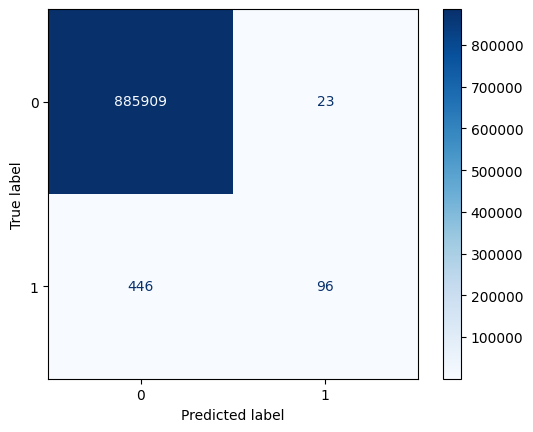

In [16]:
## confusion matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


AUC:, 0.9903224967846316


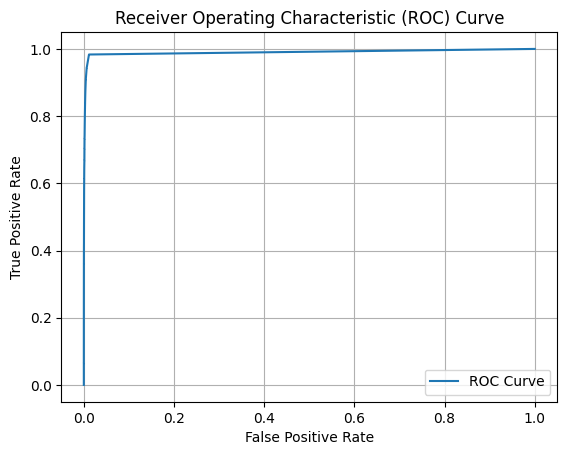

In [17]:
## AUC and ROC curve
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:,',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
#plt.savefig('roc.png')
plt.show()


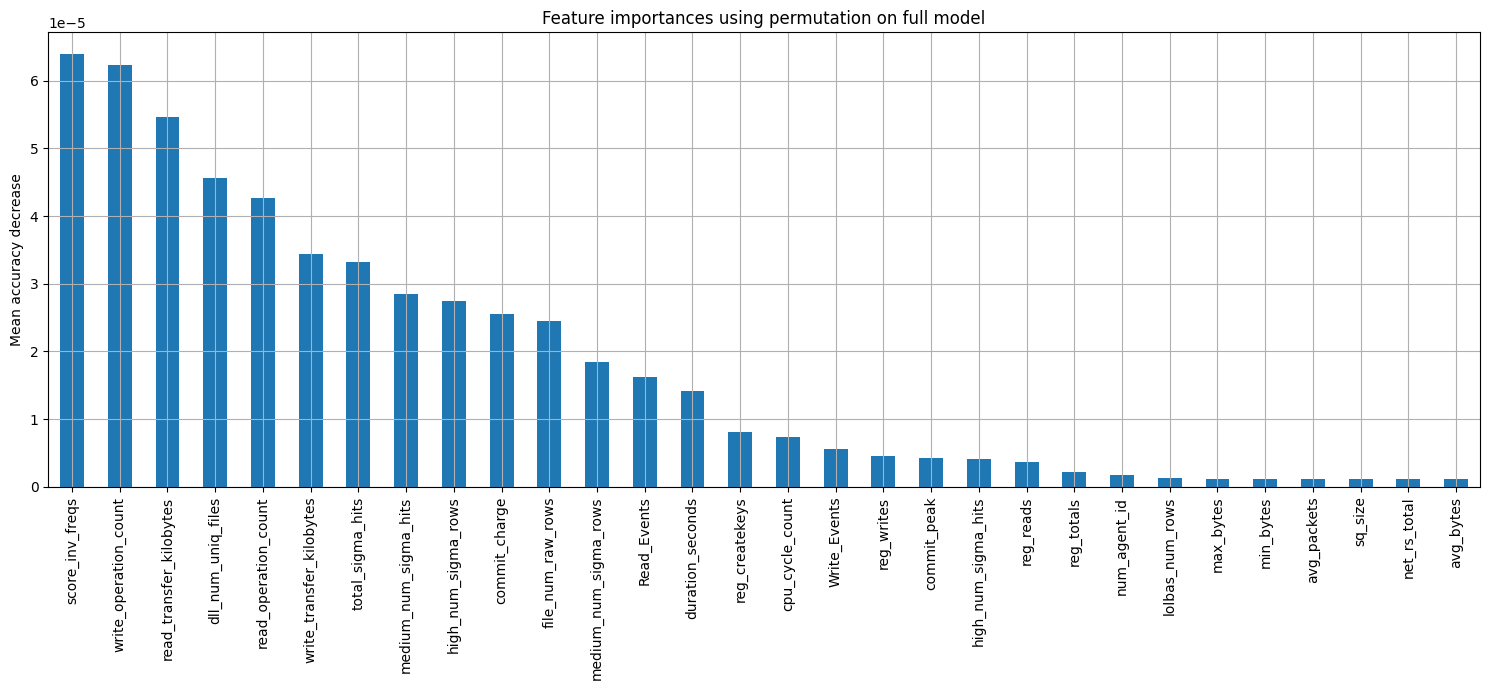

In [18]:
## variable permutation importance -- this takes a few minutes
result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=4
)

## plot top ones
_top = 30
forest_importances = pd.Series(result.importances_mean, index=num_col).sort_values(ascending=False)[:_top]
fig, ax = plt.subplots(figsize=(15,7))
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.grid()
plt.show()


## Empirical CDF embedding

In [19]:
from scipy.stats import ecdf
## pick some threshold
top_num_features = forest_importances.index[forest_importances>2e-6] 
M = process[top_num_features]

scaler = StandardScaler()
Embedding_scaled = scaler.fit_transform(M.to_numpy())

E = []
for x in Embedding_scaled.T:
    res = ecdf(x)
    E.append(list(res.cdf.evaluate(x)))
Embedding_ecdf = np.array(E).T


In [20]:
import numba
import umap

sample = 10000 ## this is very slow - only show part of the data
D = Embedding_ecdf[:sample]
# reducer = umap.UMAP(n_neighbors=15, metric='manhattan')
# embedding = reducer.fit_transform(D)

w = forest_importances[top_num_features]
w = np.array(w)/sum(w)

@numba.njit()
def weighted_manhattan(a, b):
    total = 0.0
    for i in range(a.shape[0]):
        total += w[i] * ( np.abs(a[i] - b[i]) )
    return total

reducer = umap.UMAP(
    n_neighbors=15,
    metric=weighted_manhattan, 
)

embedding = reducer.fit_transform(D)


/work/home/fcthebe/Acme4/Wintap-Analytics/2025-acme4-explore/.venv/lib/python3.13/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(


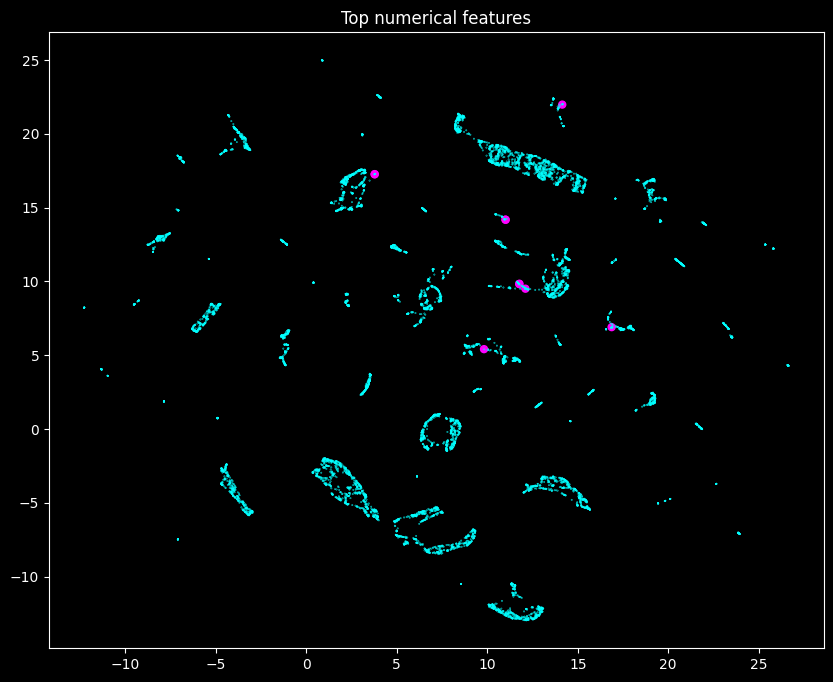

In [21]:
# plot it - color w.r.t. response variable (bad/nonbad)
C = y[:sample]
S = .1 + 25*y[:sample]
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=S, c=C, cmap='cool' )
plt.title('Top numerical features')
plt.show()


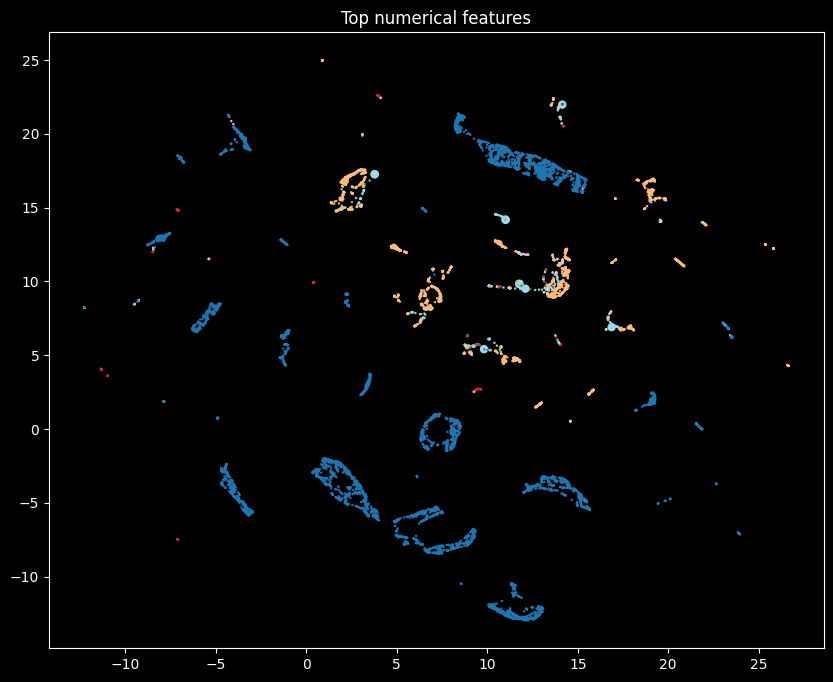

In [34]:
## color w.r.t. root process name
nc = 6
_dct = {v:k for k,v in enumerate([x[0] for x in Counter(process.process_name).most_common(6)])}
C = [_dct.get(i, 6) for i in process['process_name'][:sample]]
S = .5 + 25*y[:sample]
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=S, c=C, cmap='tab20' )
plt.title('Top numerical features')
#plt.savefig('embedding.png')
plt.show()
plt.style.use('default')


# Extra -- more of the same as a pipeline

* many categorical features contain information about the user, and thus are omitted
* some are also highly correlated (ex: SHA1 and MD5 hashes)


In [23]:
## categorical features
cat_col = ['process_name', 'file_md5']
for f in cat_col:
    print(f, len(set(process[f])))


process_name 423
file_md5 582


In [24]:
## Cramer's V score - "correlation" in [0,1] range
cramers_v_value = pt.cramers_v(process['process_name'], process['file_md5'].fillna(''))
print(f"Cramer's V: {cramers_v_value}")


Cramer's V: 0.9334241078513953


### Random forest pipeline

* including the categorical features
 

In [25]:
# Define numerical and categorical features
numerical_features = list(top_num_features)
categorical_features = cat_col

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    process[numerical_features+categorical_features], process['is_bad'], test_size=0.5, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False, with_std=False)) ## no need to scale, just map to floats
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=object))
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=24))
])

# Train the model
rf_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
## predict
y_pred_proba = rf_pipeline.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:',auc(fpr, tpr))


AUC: 0.9726671327085156


In [27]:
%%time
## this takes a few minutes
f_importance = permutation_importance(rf_pipeline, X_test, y_test, n_jobs=4, n_repeats=10, random_state=42) #


CPU times: user 30 s, sys: 2.07 s, total: 32.1 s
Wall time: 2min 58s


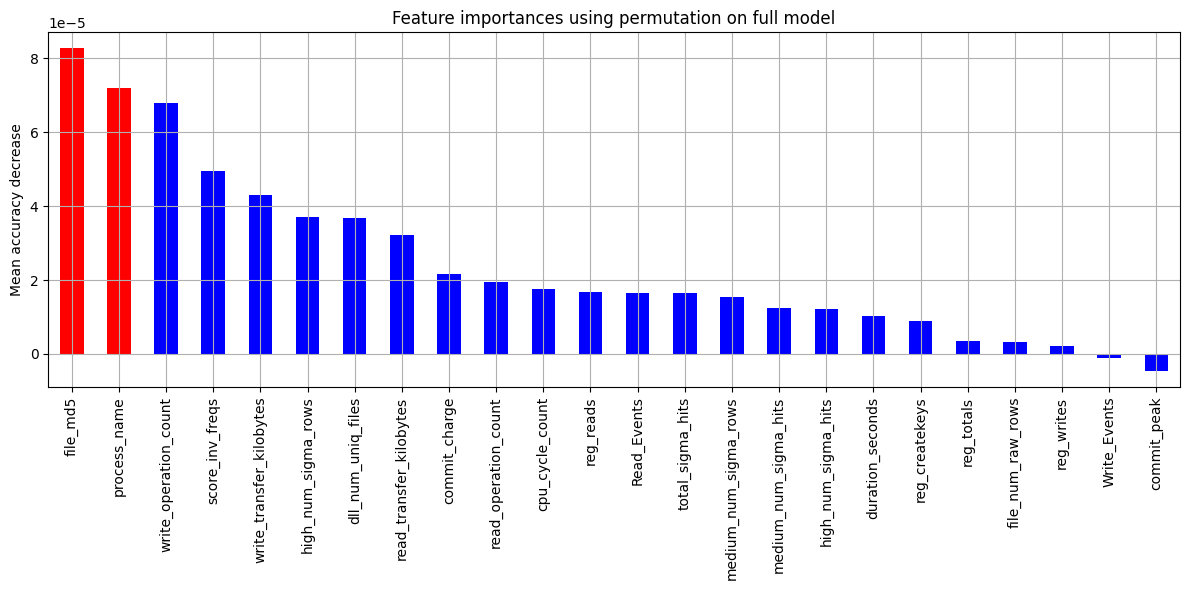

In [28]:
## plot top ones
my_col = ['red','blue']
_top = 30
forest_importances = pd.Series(f_importance.importances_mean, index=numerical_features+categorical_features).sort_values(ascending=False)[:_top]
cls = np.repeat(0,len(forest_importances))
cls[ [f in num_col for f in forest_importances.index] ] = 1

fig, ax = plt.subplots(figsize=(12,6))
forest_importances.plot.bar(ax=ax, color=[my_col[i] for i in cls])
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.grid()
plt.show()


### CART pipeline - high interpretability

In [29]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
#    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False, with_std=False))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=object))
    ]
)

cart_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=321, max_depth=6, class_weight={0:1, 1:10}))
])

# Train the model
cart_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
## predict
y_pred_proba = rf_pipeline.predict_proba(X_test)[:,1]


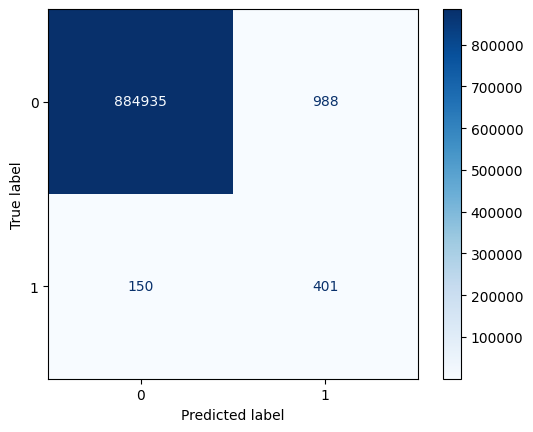

In [31]:
## Confusion matrix
cm = confusion_matrix(y_test,y_pred_proba>0.1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf.classes_)
disp.plot(cmap='Blues') 
#disp.plot()
plt.show()


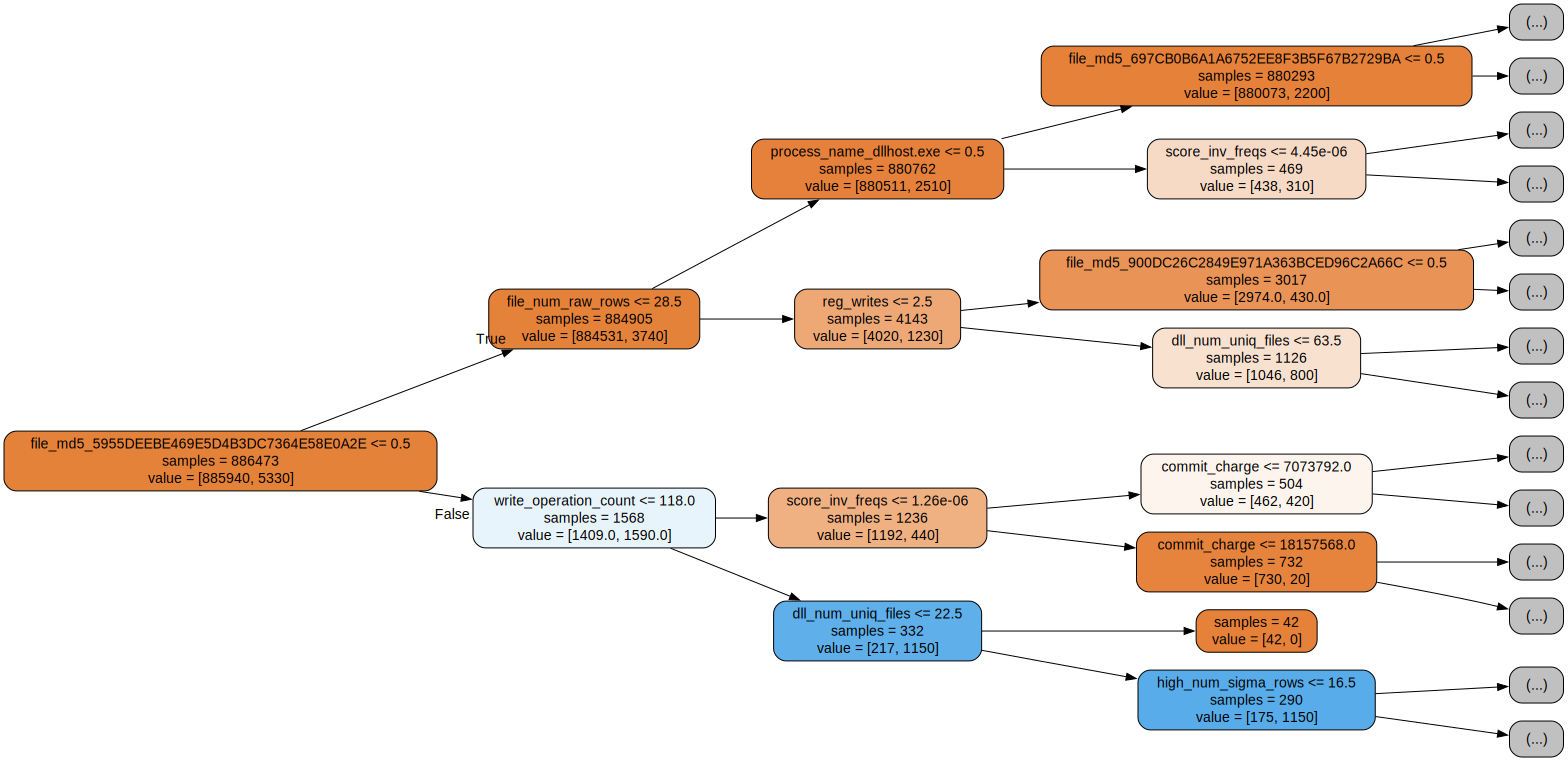

In [32]:
fitted_tree = cart_pipeline.named_steps['classifier']
encoded_feature_names = numerical_features + \
                        list(cart_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

dot_data = export_graphviz(fitted_tree,
                           feature_names=encoded_feature_names,
                           filled=True,  
                           max_depth=3, 
                           precision=8,
                           rotate=True,
                           impurity=False, 
                           rounded=True,
                           proportion=False)
graph = graphviz.Source(dot_data)
display(graph)


In [33]:
_df = (process[process['file_md5'] == '5955DEEBE469E5D4B3DC7364E58E0A2E'])
print(list(_df.filename)[0])
Counter(_df.is_bad)


c:\program files (x86)\microsoft\edge\application\msedge.exe


Counter({0: 2766, 1: 325})